## Machine Learning Saliency Detection

Running semantic extraction on cpu...


c:\Users\Simon\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Simon\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to C:\Users\Simon/.cache\torch\hub\checkpoints\fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:12<00:00, 11.6MB/s] 


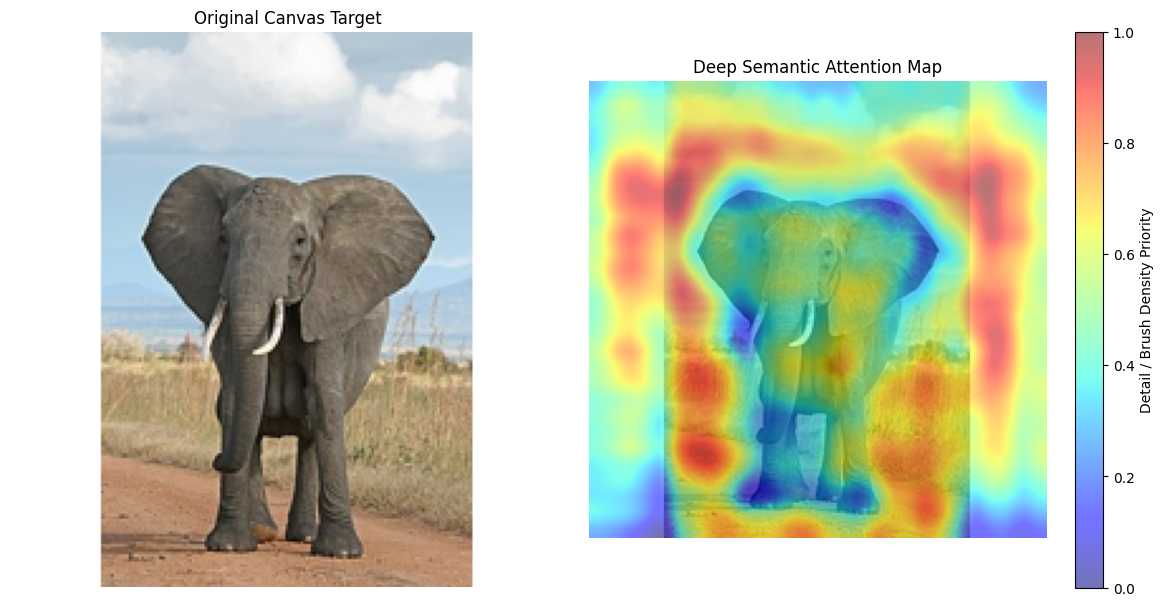

In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
IMAGE_SIZE = 220

# 1. Load your PIL image
pil_image = Image.open("C:/Users/Simon/Documents/projecten/paint-bot/images/elephant.jpg").convert('RGB')

# 2. Preprocess exactly how your paint-bot and neural networks expect it
resized_image = ImageOps.pad(pil_image, (IMAGE_SIZE, IMAGE_SIZE), color=(255, 255, 255))

# 3. Define Image Transformation for Deep Learning Model (ImageNet normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(resized_image).unsqueeze(0) # Add batch dimension

# 4. Use a pre-trained Deep Semantic Network (PyTorch native)
# We use an FCN (Fully Convolutional Network) with a ResNet-50 backbone.
# Because it is trained on 1000s of real-world objects, its intermediate feature maps 
# inherently highlight high-level semantic concepts (like eyes, heads, silhouettes).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running semantic extraction on {device}...")

# Load a lightweight segmenter/saliency backbone
model = models.segmentation.fcn_resnet50(pretrained=True).to(device)
model.eval()

# 5. Extract the attention activation maps
with torch.no_grad():
    input_tensor = input_tensor.to(device)
    output = model(input_tensor)['out'][0] # Shape: [21, 220, 220]
    
    # Take the variance or maximum activation across the semantic channels.
    # This captures whatever features stand out strongly to the network's "brain".
    saliency_map = torch.max(output, dim=0)[0].cpu().numpy()

# 6. Normalize the map to a clean [0.0, 1.0] scale
saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min() + 1e-8)

# 7. Apply a slight Gaussian blur to make it smooth, replicating organic human gaze maps
import scipy.ndimage
saliency_map = scipy.ndimage.gaussian_filter(saliency_map, sigma=3)

# Normalize once more post-blur
saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min() + 1e-8)

# --- 8. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original Image
axes[0].imshow(resized_image)
axes[0].set_title("Original Canvas Target")
axes[0].axis("off")

# Semantic Gaze Overlay
axes[1].imshow(resized_image)
im = axes[1].imshow(saliency_map, cmap='jet', alpha=0.55)
axes[1].set_title("Deep Semantic Attention Map")
axes[1].axis("off")

# Colorbar for painting threshold values
fig.colorbar(im, ax=axes[1], label="Detail / Brush Density Priority")

plt.tight_layout()
plt.show()